<a href="https://colab.research.google.com/github/jeremiahoclark/open_source_colabs/blob/main/ai_data_industry_survey_eda_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI Data Industry Survey EDA to Google Sheets

This Colab notebook uploads the three survey CSVs, preserves duplicate survey headers, merges the responses, and creates a Google Sheet with four tabs:

1. `Merged` - starter EDA dashboard at the top, merged response table below it
2. `IC` - individual contributor survey responses
3. `Managers` - manager survey responses
4. `Combined` - combined manager and IC survey responses

The notebook also creates reusable pandas summary functions and embedded Google Sheets charts so you can add more questions later.

Design direction follows the So What Data `Broadsheet` guide: deep ink text, warm limestone background, slate borders, and Boston Clay as the chart accent.

In [ ]:
# Notebook configuration
SPREADSHEET_TITLE = "AI Data Industry Survey EDA"
MERGED_DATA_START_ROW = 110  # Keeps the Merged tab dashboard visible above the raw table.
DROP_PII_FOR_SHEETS = False  # Set True before sharing if you want to remove names/emails/LinkedIn columns.

SURVEY_LABELS = {
    "ic": "IC",
    "manager": "Managers",
    "combined": "Combined",
}

# Broadsheet design tokens from /Users/kingj/dev/sowhatdata/DESIGN.md
DESIGN = {
    "primary": "#1A1C1E",    # deep ink
    "secondary": "#6C7278",  # slate
    "tertiary": "#B8422E",   # Boston Clay
    "neutral": "#F7F5F2",    # warm limestone
    "white": "#FFFFFF",
}

EXPECTED_SURVEYS = set(SURVEY_LABELS)

## Starter EDA questions

These questions are intentionally broad. The helper functions later in the notebook make it easy to filter by survey, respondent type, role, company, or any canonical field and then rerun the same summaries.

1. How many usable responses came from each survey and respondent type?
2. Which AI usage modes are most common across the data industry respondents?
3. How does AI usage differ between managers and ICs?
4. How mature is organizational AI adoption across respondents?
5. Who appears to own AI adoption inside organizations?
6. What build stage are organizations in for AI systems?
7. How common are formal governance processes and governance/safety training?
8. Which AI downsides or risks show up most often?
9. How ready is data infrastructure for AI, and which capabilities are present?
10. For managers, what efficiency lift, upskilling supports, and training barriers are showing up?

In [ ]:
# Imports and Google authentication
import importlib
import math
import re
import subprocess
import sys
from collections import OrderedDict
from datetime import datetime, timezone
from pathlib import Path


def ensure_package(import_name, pip_name=None):
    """Import a package, installing it in Colab only if it is missing."""
    try:
        return importlib.import_module(import_name)
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pip_name or import_name])
        return importlib.import_module(import_name)

pd = ensure_package("pandas")
np = ensure_package("numpy")
plt = ensure_package("matplotlib.pyplot", "matplotlib")
gspread = ensure_package("gspread")

from google.colab import auth, files
from google.auth import default
from gspread.utils import rowcol_to_a1

SCOPES = [
    "https://www.googleapis.com/auth/spreadsheets",
    "https://www.googleapis.com/auth/drive",
]

auth.authenticate_user()
creds, _ = default(scopes=SCOPES)
gc = gspread.authorize(creds)

print("Authenticated. Next cell will ask you to upload the three survey CSV files.")

Authenticated. Next cell will ask you to upload the three survey CSV files.


In [ ]:
# Upload the three CSVs.
# Expected names contain B49, B52, and 5C. If your filenames differ, update identify_survey_from_name().
uploaded = files.upload()
CSV_PATHS = [Path(name) for name in uploaded.keys() if name.lower().endswith(".csv")]

print("Uploaded CSVs:")
for path in CSV_PATHS:
    print("-", path)

Saving responses-dkgmG64W-01KSYZRS65SG9XPH4EAPJ2QR86-KORMQPN4O6ED5HPJOGGTRE5C.csv to responses-dkgmG64W-01KSYZRS65SG9XPH4EAPJ2QR86-KORMQPN4O6ED5HPJOGGTRE5C.csv
Saving responses-FXzC5ex7-01KSYZR7AB90WZVW46Z508Q2F7-B1U5M6EROFUK190D1M2ANB49.csv to responses-FXzC5ex7-01KSYZR7AB90WZVW46Z508Q2F7-B1U5M6EROFUK190D1M2ANB49.csv
Saving responses-oV2sdf9s-01KSYZPHMWTWZXMXFM3VHQ3ZW3-F7GT6KD02VGNIT8YH3XSWB52.csv to responses-oV2sdf9s-01KSYZPHMWTWZXMXFM3VHQ3ZW3-F7GT6KD02VGNIT8YH3XSWB52.csv
Uploaded CSVs:
- responses-dkgmG64W-01KSYZRS65SG9XPH4EAPJ2QR86-KORMQPN4O6ED5HPJOGGTRE5C.csv
- responses-FXzC5ex7-01KSYZR7AB90WZVW46Z508Q2F7-B1U5M6EROFUK190D1M2ANB49.csv
- responses-oV2sdf9s-01KSYZPHMWTWZXMXFM3VHQ3ZW3-F7GT6KD02VGNIT8YH3XSWB52.csv


In [ ]:
# CSV loading and schema normalization

def clean_header(value):
    text = "" if value is None else str(value)
    text = text.replace("\ufeff", "")
    text = re.sub(r"\s+", " ", text).strip()
    return text or "unnamed"


def make_unique(headers):
    """Keep duplicate survey question headers while making dataframe columns addressable."""
    seen = {}
    unique = []
    for header in headers:
        base = clean_header(header)
        seen[base] = seen.get(base, 0) + 1
        unique.append(base if seen[base] == 1 else f"{base}__{seen[base]}")
    return unique


def base_col(column):
    return re.sub(r"__\d+$", "", str(column))


def norm_key(value):
    text = base_col(value)
    text = text.translate(str.maketrans({
        "’": "'",
        "‘": "'",
        "“": '"',
        "”": '"',
        "—": "-",
        "–": "-",
        "\u00a0": " ",
    }))
    text = re.sub(r"\s+", " ", text).strip().lower()
    return text


def slugify(value, max_len=70):
    text = norm_key(value)
    text = re.sub(r"[^a-z0-9]+", "_", text).strip("_")
    return text[:max_len].strip("_") or "field"


def identify_survey_from_name(path):
    name = str(path).upper()
    if "B49" in name:
        return "ic"
    if "B52" in name:
        return "manager"
    if "5C" in name:
        return "combined"
    raise ValueError(f"Could not identify survey from filename: {path}")


def read_csv_preserve_duplicate_headers(path):
    raw = pd.read_csv(path, header=None, dtype=str, keep_default_na=False, na_filter=False, encoding="utf-8-sig")
    headers = make_unique(raw.iloc[0].tolist())
    df = raw.iloc[1:].reset_index(drop=True).copy()
    df.columns = headers
    return df


def nonempty_series(series):
    return series.fillna("").astype(str).str.strip().ne("")


def first_nonempty_by_base(df, base_names):
    if isinstance(base_names, str):
        base_names = [base_names]
    wanted = {norm_key(name) for name in base_names}
    cols = [col for col in df.columns if norm_key(col) in wanted]
    if not cols:
        return pd.Series([""] * len(df), index=df.index)
    values = df[cols].replace("", pd.NA)
    return values.bfill(axis=1).iloc[:, 0].fillna("")


def columns_matching_labels(df, labels, candidates=None):
    candidate_cols = list(candidates) if candidates is not None else list(df.columns)
    normalized_cols = {col: norm_key(col) for col in candidate_cols}
    result = OrderedDict()
    for label in labels:
        key = norm_key(label)
        result[label] = [col for col, col_key in normalized_cols.items() if col_key == key]
    return result


def columns_in_windows(df, after_labels=None, before_labels=None):
    """Return columns after each anchor and before the next stop label.

    This keeps repeated labels like 'Data / analytics leadership' separated by survey section.
    """
    if not after_labels:
        return list(df.columns)

    after_keys = {norm_key(label) for label in after_labels}
    before_keys = {norm_key(label) for label in (before_labels or [])}
    col_keys = [norm_key(col) for col in df.columns]
    windows = []

    for start_idx, key in enumerate(col_keys):
        if key not in after_keys:
            continue
        end_idx = len(df.columns)
        for idx in range(start_idx + 1, len(df.columns)):
            if col_keys[idx] in before_keys:
                end_idx = idx
                break
        windows.extend(df.columns[start_idx + 1:end_idx])
    return windows


def selected_any(df, cols):
    if not cols:
        return pd.Series([False] * len(df), index=df.index)
    return df[cols].apply(lambda row: any(str(v).strip() for v in row), axis=1)

In [ ]:
# Survey-specific fields and multi-select option groups
AI_USAGE_OPTIONS = [
    "Not using AI",
    "Using AI for chat and text (e.g. ChatGPT, Gemini)",
    "Using AI for coding (e.g. Copilot, Claude Code, Cursor)",
    "Building AI agents or workflows for personal use",
    "Building AI agents for internal teams or external users",
]

AI_OWNER_OPTIONS = [
    "Executive leadership (C-suite, VP)",
    "A dedicated AI or innovation team",
    "Data / analytics leadership",
    "Engineering leadership",
    "No one",
    "Everyone - it's decentralized",
    "I don't know",
]

BUILD_STAGE_OPTIONS = [
    "Not building AI systems; we are only using existing tools",
    "Exploring or prototyping",
    "Building for internal users",
    "Deployed internal solutions with monitoring and maintenance",
    "Building for external users / customers",
    "Deployed external solutions with monitoring and maintenance",
]

GOVERNANCE_OWNER_OPTIONS = [
    "A dedicated AI governance, risk, or safety function",
    "Security, legal, or compliance team",
    "Data / analytics leadership",
    "Engineering leadership",
    "Individual teams own governance for their AI use cases",
    "No clear owner - it's ad hoc or unclear",
    "I don't know",
]

DOWNSIDE_OPTIONS = [
    "Technical debt or code quality issues",
    "Moving fast on delivery but cutting corners on validation",
    "Team skill atrophy in areas AI now handles",
    "Uneven adoption across the team creating friction",
    "Fear or anxiety about AI replacing their role",
    "Resistance to changing established workflows",
    "Business partners accessing data they shouldn't",
    "None; we haven't experienced significant downsides",
]

AI_TOOL_OPTIONS = [
    "AI chat tools (e.g. ChatGPT, Gemini, Claude)",
    "AI coding assistants (e.g. Copilot, Cursor, Claude Code)",
    "AI features embedded in existing tools (e.g. Notion AI, Slack AI)",
    "MCPs",
    "Agent orchestration or workflow tools",
    "Custom-built internal AI tools",
    "None",
]

DATA_CAPABILITY_OPTIONS = [
    "Centralized data platform or warehouse",
    "Data quality monitoring",
    "Data catalog or documentation",
    "Semantic layer",
    "Defined data ownership and stewardship",
    "Data governance policies",
    "None of the above",
]

ROLE_CHANGE_OPTIONS = [
    "Shift toward softer skills (communication, storytelling, stakeholder management)",
    "More cross-functional collaboration",
    "Role boundaries blurring (e.g. data and engineering merging)",
    "Data team is being absorbed by a different team",
    "Expectation to do tasks outside Data scope (e.g. design, engineering)",
    "Increased influence and value among business partners",
    "Decreased influence and value among business partners",
    "Not seeing significant changes",
]

UPSKILLING_SUPPORT_OPTIONS = [
    "Dedicated time set aside for learning",
    "Goals or KPIs around skill development",
    "Structured workshops or bootcamps",
    "Knowledge sharing sessions (e.g. lunch & learns, demos)",
    "Self-paced learning platforms (e.g. LinkedIn Learning, Coursera)",
    "L&D budget",
    "Sending team members to industry conferences",
    "Centralized knowledge base or tools",
    "AI SMEs, champions, or power users",
    "None of the above",
]

TRAINING_BARRIER_OPTIONS = [
    "Not enough time",
    "Not enough budget",
    "Lack of interest or motivation from the team",
    "Don't know where to start",
    "Don't have a trusted training partner or vendor",
    "Hard to measure impact of training",
    "Not sure what skills to prioritize",
    "This isn't something I've focused on",
]

MULTI_SELECT_GROUPS = OrderedDict({
    "ai_usage": {
        "options": AI_USAGE_OPTIONS,
    },
    "ai_adoption_owner": {
        "options": AI_OWNER_OPTIONS,
        "after": ["How would you describe your organization's approach to AI adoption?"],
        "before": ["Not building AI systems; we are only using existing tools"],
    },
    "ai_build_stage": {
        "options": BUILD_STAGE_OPTIONS,
    },
    "governance_owner": {
        "options": GOVERNANCE_OWNER_OPTIONS,
        "after": ["Has your team received training on AI governance and safety?"],
        "before": [
            "Technical debt or code quality issues",
            "How much influence do you have in AI governance at your org?",
            "How would you describe your organization's data infrastructure readiness for AI?",
        ],
    },
    "downsides": {
        "options": DOWNSIDE_OPTIONS,
    },
    "ai_tools": {
        "options": AI_TOOL_OPTIONS,
    },
    "data_capabilities": {
        "options": DATA_CAPABILITY_OPTIONS,
    },
    "role_changes": {
        "options": ROLE_CHANGE_OPTIONS,
    },
    "upskilling_supports": {
        "options": UPSKILLING_SUPPORT_OPTIONS,
    },
    "training_barriers": {
        "options": TRAINING_BARRIER_OPTIONS,
    },
})

FLAG_LABELS = {}


def respondent_type_for(df, survey_code):
    if survey_code == "ic":
        default = "IC"
    elif survey_code == "manager":
        default = "Manager"
    else:
        default = "Mixed/unknown"

    source_role = first_nonempty_by_base(df, "Which best describes your role?")

    def classify(value):
        text = str(value).strip().lower()
        if not text:
            return default
        if "individual" in text or text == "ic" or " ic" in text:
            return "IC"
        if any(token in text for token in ["manager", "lead", "head", "director", "vp", "executive"]):
            return "Manager"
        return value

    return source_role.map(classify)


def add_multi_select_flags(df):
    for group_name, spec in MULTI_SELECT_GROUPS.items():
        window_cols = columns_in_windows(df, spec.get("after"), spec.get("before"))
        option_cols = columns_matching_labels(df, spec["options"], candidates=window_cols)
        for label, cols in option_cols.items():
            flag_col = f"eda_{group_name}__{slugify(label)}"
            df[flag_col] = selected_any(df, cols)
            FLAG_LABELS[flag_col] = label
    return df


def prepare_survey_df(df, survey_code, source_file):
    prepared = df.copy()
    prepared.insert(0, "eda_survey_code", survey_code)
    prepared.insert(1, "eda_survey_label", SURVEY_LABELS[survey_code])
    prepared.insert(2, "eda_source_file", str(source_file))
    prepared.insert(3, "eda_source_row", range(2, len(prepared) + 2))

    prepared["eda_respondent_type"] = respondent_type_for(prepared, survey_code)
    prepared["eda_company"] = first_nonempty_by_base(prepared, "Company")
    prepared["eda_role_title"] = first_nonempty_by_base(prepared, "Role")

    first_name = first_nonempty_by_base(prepared, "First Name")
    last_name = first_nonempty_by_base(prepared, "Last Name")
    full_name = (first_name + " " + last_name).str.strip()
    fallback_name = first_nonempty_by_base(prepared, "Name")
    prepared["eda_respondent_name"] = full_name.where(full_name.ne(""), fallback_name)

    prepared["eda_ai_adoption_approach"] = first_nonempty_by_base(prepared, "How would you describe your organization's approach to AI adoption?")
    prepared["eda_formal_ai_goals"] = first_nonempty_by_base(prepared, [
        "Does your team have formal goals around AI adoption?",
        "Does your org have formal goals around AI adoption and impact?",
    ])
    prepared["eda_governance_process"] = first_nonempty_by_base(prepared, "Does your organization have a formal process, team or council for managing AI governance?")
    prepared["eda_governance_training"] = first_nonempty_by_base(prepared, "Has your team received training on AI governance and safety?")
    prepared["eda_data_readiness"] = first_nonempty_by_base(prepared, "How would you describe your organization's data infrastructure readiness for AI?")
    prepared["eda_impact_metrics"] = first_nonempty_by_base(prepared, "Does your org have metrics to measure the impact of AI initiatives?")
    prepared["eda_metrics_used"] = first_nonempty_by_base(prepared, "Does your org use these metrics to evaluate existing AI initiatives and find new opportunities?")
    prepared["eda_efficiency_improvement"] = first_nonempty_by_base(prepared, "How much has AI improved your team's efficiency?")
    prepared["eda_ai_goals_text"] = first_nonempty_by_base(prepared, "If your team has formal AI goals, what are they?")
    prepared["eda_upskilling_effective_text"] = first_nonempty_by_base(prepared, "What has been most effective for upskilling your team?")
    prepared["eda_response_type"] = first_nonempty_by_base(prepared, "Response Type")
    prepared["eda_submit_date_utc"] = first_nonempty_by_base(prepared, "Submit Date (UTC)")

    prepared = add_multi_select_flags(prepared)
    return prepared


def drop_pii(df):
    pii_terms = ["email", "work email", "linkedin", "first name", "last name", "name"]
    keep = []
    for col in df.columns:
        key = norm_key(col)
        if any(term in key for term in pii_terms) and not col.startswith("eda_survey"):
            continue
        keep.append(col)
    return df[keep]

In [ ]:
# Load, prepare, and merge the uploaded CSVs
survey_files = OrderedDict()
for path in CSV_PATHS:
    survey_code = identify_survey_from_name(path)
    survey_files[survey_code] = path

missing = EXPECTED_SURVEYS - set(survey_files)
if missing:
    raise ValueError(f"Missing expected survey CSV(s): {sorted(missing)}")

raw_dfs = OrderedDict()
prepared_dfs = OrderedDict()
for survey_code in ["ic", "manager", "combined"]:
    path = survey_files[survey_code]
    raw = read_csv_preserve_duplicate_headers(path)
    prepared = prepare_survey_df(raw, survey_code, path.name)
    raw_dfs[survey_code] = raw
    prepared_dfs[survey_code] = prepared
    print(f"{SURVEY_LABELS[survey_code]}: {prepared.shape[0]} rows, {prepared.shape[1]} columns")

merged_df = pd.concat(prepared_dfs.values(), ignore_index=True, sort=False)

front_cols = [
    "eda_survey_code", "eda_survey_label", "eda_source_file", "eda_source_row",
    "eda_respondent_type", "eda_respondent_name", "eda_company", "eda_role_title",
    "eda_response_type", "eda_submit_date_utc", "eda_ai_adoption_approach",
    "eda_formal_ai_goals", "eda_governance_process", "eda_governance_training",
    "eda_data_readiness", "eda_impact_metrics", "eda_metrics_used", "eda_efficiency_improvement",
]
front_cols = [col for col in front_cols if col in merged_df.columns]
remaining_cols = [col for col in merged_df.columns if col not in front_cols]
merged_df = merged_df[front_cols + remaining_cols]

if DROP_PII_FOR_SHEETS:
    merged_for_sheet = drop_pii(merged_df)
    prepared_for_sheet = {code: drop_pii(df) for code, df in prepared_dfs.items()}
else:
    merged_for_sheet = merged_df
    prepared_for_sheet = prepared_dfs

print("Merged:", merged_df.shape)
display(merged_df[front_cols].head())

IC: 33 rows, 165 columns
Managers: 56 rows, 203 columns
Combined: 10 rows, 267 columns
Merged: (99, 269)


,eda_survey_code,eda_survey_label,eda_source_file,eda_source_row,eda_respondent_type,eda_respondent_name,eda_company,eda_role_title,eda_response_type,eda_submit_date_utc,eda_ai_adoption_approach,eda_formal_ai_goals,eda_governance_process,eda_governance_training,eda_data_readiness,eda_impact_metrics,eda_metrics_used,eda_efficiency_improvement
0,ic,IC,responses-FXzC5ex7-01KSYZR7AB90WZVW46Z508Q2F7-...,2,IC,Preeti Jain,Dell,Data Scientist,completed,2026-05-30 22:08:19,We have a formal AI strategy with clear priori...,Yes,Yes,"Yes, we have regular or ongoing training","Our data is well-organized, documented, and re...",I don't know,I don't know,
1,ic,IC,responses-FXzC5ex7-01KSYZR7AB90WZVW46Z508Q2F7-...,3,IC,desi pilla,paramount,senior data scientist,completed,2026-05-29 17:42:28,It's mostly driven by individual teams or peop...,No,Yes,"No, this is not a priority right now",We have good databases but lack semantic layer...,No,No,
2,ic,IC,responses-FXzC5ex7-01KSYZR7AB90WZVW46Z508Q2F7-...,4,IC,Erica Duke,Milken Institute,Senior Associate,completed,2026-05-29 16:31:57,It's mostly driven by individual teams or peop...,No,No,We've had one-off training,We have data infrastructure but gaps in data q...,No,No,
3,ic,IC,responses-FXzC5ex7-01KSYZR7AB90WZVW46Z508Q2F7-...,5,IC,Hillary Onah,DHIN,Data science analyst,partial,,We have a general direction but no formal stra...,,,,,,,
4,ic,IC,responses-FXzC5ex7-01KSYZR7AB90WZVW46Z508Q2F7-...,6,IC,Kinza Rehman,,Power BI Analyst,completed,2026-05-29 01:08:31,It's mostly driven by individual teams or peop...,No,I don't know,I'm not sure,We have data infrastructure but gaps in data q...,I don't know,I don't know,


In [ ]:
# Reusable EDA helpers for extending the analysis
EDA_QUESTIONS = [
    "How many usable responses came from each survey and respondent type?",
    "Which AI usage modes are most common across respondents?",
    "How does AI usage differ between managers and ICs?",
    "How mature is organizational AI adoption across respondents?",
    "Who appears to own AI adoption inside organizations?",
    "What build stage are organizations in for AI systems?",
    "How common are formal governance processes and governance/safety training?",
    "Which AI downsides or risks show up most often?",
    "How ready is data infrastructure for AI, and which capabilities are present?",
    "For managers, what efficiency lift, upskilling supports, and training barriers are showing up?",
]


def filter_responses(df, respondent_type=None, survey_label=None, completed_only=False):
    out = df.copy()
    if respondent_type:
        wanted = {respondent_type} if isinstance(respondent_type, str) else set(respondent_type)
        out = out[out["eda_respondent_type"].isin(wanted)]
    if survey_label:
        wanted = {survey_label} if isinstance(survey_label, str) else set(survey_label)
        out = out[out["eda_survey_label"].isin(wanted)]
    if completed_only and "eda_response_type" in out.columns:
        out = out[out["eda_response_type"].astype(str).str.lower().eq("completed")]
    return out


def summarize_single_select(df, column, label=None, include_blank=False):
    label = label or column
    values = df[column].fillna("").astype(str).str.strip()
    if not include_blank:
        values = values[values.ne("")]
    total = max(len(values), 1)
    summary = (
        values.replace("", "(blank)")
        .value_counts(dropna=False)
        .rename_axis(label)
        .reset_index(name="responses")
    )
    summary["pct_of_answered"] = summary["responses"] / total
    return summary


def summarize_flags(df, prefix, label_col="option"):
    flag_cols = [col for col in df.columns if col.startswith(prefix)]
    rows = []
    denominator = max(len(df), 1)
    for col in flag_cols:
        count = df[col].fillna(False).astype(bool).sum()
        rows.append({
            label_col: FLAG_LABELS.get(col, col.replace(prefix, "")),
            "responses": int(count),
            "pct_of_responses": count / denominator,
        })
    return pd.DataFrame(rows).sort_values("responses", ascending=False).reset_index(drop=True)


def summarize_flags_by_group(df, prefix, group_col="eda_respondent_type"):
    flag_cols = [col for col in df.columns if col.startswith(prefix)]
    rows = []
    for group_value, group_df in df.groupby(group_col, dropna=False):
        denominator = max(len(group_df), 1)
        for col in flag_cols:
            count = group_df[col].fillna(False).astype(bool).sum()
            rows.append({
                group_col: group_value or "(blank)",
                "option": FLAG_LABELS.get(col, col.replace(prefix, "")),
                "responses": int(count),
                "pct_of_group": count / denominator,
            })
    return pd.DataFrame(rows).sort_values([group_col, "responses"], ascending=[True, False]).reset_index(drop=True)


def build_eda_tables(df):
    tables = OrderedDict()
    tables["questions"] = pd.DataFrame({"#": range(1, len(EDA_QUESTIONS) + 1), "question": EDA_QUESTIONS})

    completed = filter_responses(df, completed_only=True)
    tables["metrics"] = pd.DataFrame([
        {"metric": "Total responses", "value": len(df)},
        {"metric": "Completed responses", "value": len(completed)},
        {"metric": "Manager responses", "value": int((df["eda_respondent_type"] == "Manager").sum())},
        {"metric": "IC responses", "value": int((df["eda_respondent_type"] == "IC").sum())},
        {"metric": "Survey tabs merged", "value": df["eda_survey_label"].nunique()},
    ])

    tables["responses_by_source"] = (
        df.groupby("eda_survey_label", dropna=False).size().reset_index(name="responses")
        .sort_values("responses", ascending=False)
    )
    tables["responses_by_role"] = (
        df.groupby("eda_respondent_type", dropna=False).size().reset_index(name="responses")
        .sort_values("responses", ascending=False)
    )
    tables["ai_usage"] = summarize_flags(df, "eda_ai_usage__")
    tables["ai_usage_by_role"] = summarize_flags_by_group(df, "eda_ai_usage__")
    tables["ai_adoption_approach"] = summarize_single_select(df, "eda_ai_adoption_approach", "adoption_approach")
    tables["ai_adoption_owner"] = summarize_flags(df, "eda_ai_adoption_owner__")
    tables["ai_build_stage"] = summarize_flags(df, "eda_ai_build_stage__")
    tables["governance_process"] = summarize_single_select(df, "eda_governance_process", "governance_process")
    tables["governance_training"] = summarize_single_select(df, "eda_governance_training", "governance_training")
    tables["governance_owner"] = summarize_flags(df, "eda_governance_owner__")
    tables["downsides"] = summarize_flags(df, "eda_downsides__")
    tables["data_readiness"] = summarize_single_select(df, "eda_data_readiness", "data_readiness")
    tables["data_capabilities"] = summarize_flags(df, "eda_data_capabilities__")
    manager_df = filter_responses(df, respondent_type="Manager")
    tables["manager_efficiency"] = summarize_single_select(manager_df, "eda_efficiency_improvement", "efficiency_improvement")
    tables["upskilling_supports"] = summarize_flags(manager_df, "eda_upskilling_supports__")
    tables["training_barriers"] = summarize_flags(manager_df, "eda_training_barriers__")
    return tables


eda_tables = build_eda_tables(merged_df)
for name, table in eda_tables.items():
    print(f"{name}: {table.shape}")

questions: (10, 2)
metrics: (5, 2)
responses_by_source: (3, 2)
responses_by_role: (2, 2)
ai_usage: (5, 3)
ai_usage_by_role: (10, 4)
ai_adoption_approach: (4, 3)
ai_adoption_owner: (7, 3)
ai_build_stage: (6, 3)
governance_process: (3, 3)
governance_training: (4, 3)
governance_owner: (7, 3)
downsides: (8, 3)
data_readiness: (5, 3)
data_capabilities: (7, 3)
manager_efficiency: (5, 3)
upskilling_supports: (10, 3)
training_barriers: (8, 3)


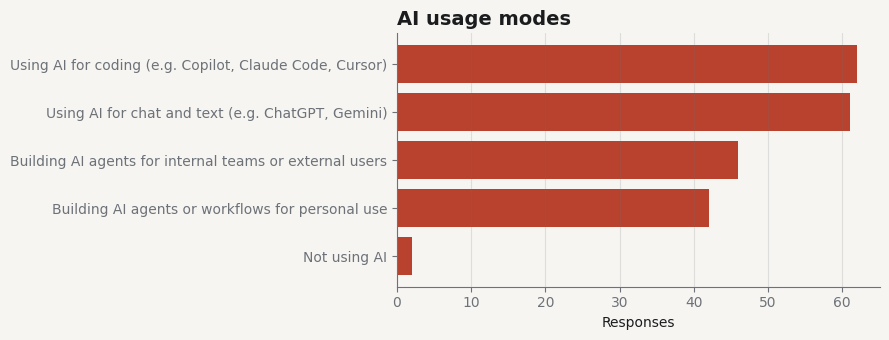

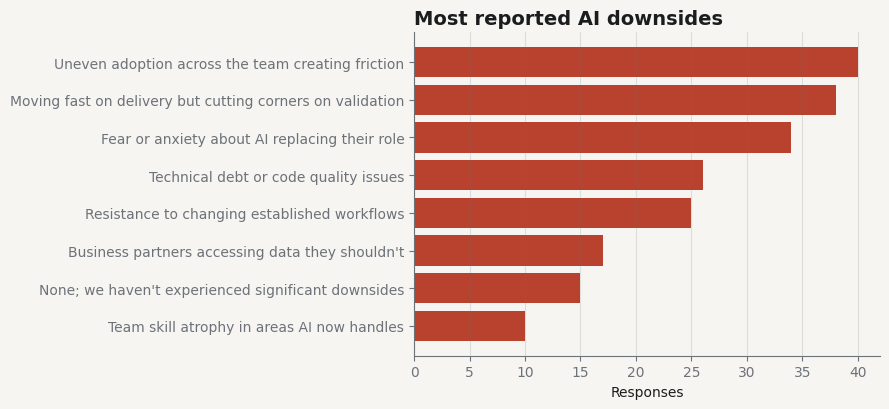

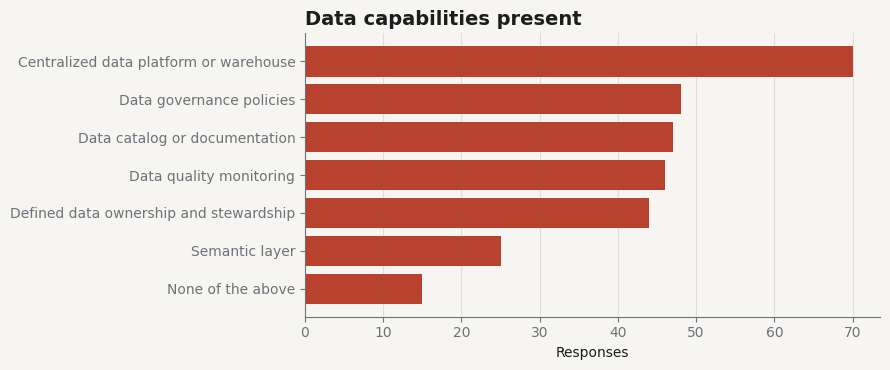

In [ ]:
# Optional in-notebook charting helpers. The Google Sheet will also receive embedded charts.
plt.style.use("default")
plt.rcParams.update({
    "figure.facecolor": DESIGN["neutral"],
    "axes.facecolor": DESIGN["neutral"],
    "axes.edgecolor": DESIGN["secondary"],
    "axes.labelcolor": DESIGN["primary"],
    "text.color": DESIGN["primary"],
    "xtick.color": DESIGN["secondary"],
    "ytick.color": DESIGN["secondary"],
    "font.size": 10,
})


def plot_summary_bar(table, category_col, value_col="responses", title=None, top_n=10):
    plot_df = table[[category_col, value_col]].head(top_n).sort_values(value_col, ascending=True)
    fig_height = max(3.5, 0.4 * len(plot_df) + 1)
    fig, ax = plt.subplots(figsize=(9, fig_height))
    ax.barh(plot_df[category_col], plot_df[value_col], color=DESIGN["tertiary"])
    ax.set_title(title or value_col, loc="left", fontsize=14, fontweight="bold")
    ax.set_xlabel("Responses")
    ax.set_ylabel("")
    ax.grid(axis="x", color=DESIGN["secondary"], alpha=0.18)
    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)
    plt.tight_layout()
    return fig, ax

plot_summary_bar(eda_tables["ai_usage"], "option", title="AI usage modes")
plot_summary_bar(eda_tables["downsides"], "option", title="Most reported AI downsides")
plot_summary_bar(eda_tables["data_capabilities"], "option", title="Data capabilities present")
plt.show()

In [ ]:
def hex_to_color(hex_value):
    hex_value = hex_value.lstrip("#")
    return {
        "red": int(hex_value[0:2], 16) / 255,
        "green": int(hex_value[2:4], 16) / 255,
        "blue": int(hex_value[4:6], 16) / 255,
    }

def sheet_values(df):
    safe = df.copy()
    safe = safe.replace([np.inf, -np.inf], "")
    safe = safe.where(pd.notna(safe), "")
    values = [list(safe.columns)] + safe.astype(object).values.tolist()
    return values

def update_values(ws, start_row, start_col, values, chunk_rows=500):
    for offset in range(0, len(values), chunk_rows):
        chunk = values[offset:offset + chunk_rows]
        range_name = rowcol_to_a1(start_row + offset, start_col)
        try:
            ws.update(values=chunk, range_name=range_name, value_input_option="RAW")
        except TypeError:
            ws.update(range_name, chunk, value_input_option="RAW")

def write_dataframe(ws, df, start_row=1, start_col=1):
    values = sheet_values(df)
    update_values(ws, start_row, start_col, values)
    return {
        "start_row": start_row,
        "start_col": start_col,
        "rows": len(values),
        "cols": len(values[0]) if values else 0,
    }

def create_or_resize_worksheet(sh, title, rows, cols, first=False):
    if first:
        ws = sh.sheet1
        ws.update_title(title)
    else:
        ws = sh.add_worksheet(title=title, rows=max(rows, 1), cols=max(cols, 1))
    ws.resize(rows=max(rows, 1), cols=max(cols, 1))
    return ws

def write_table_block(ws, title, df, start_row, start_col=1):
    update_values(ws, start_row, start_col, [[title]])
    table_info = write_dataframe(ws, df, start_row=start_row + 1, start_col=start_col)
    return {
        "title": title,
        "title_row": start_row,
        "header_row": start_row + 1,
        "start_row": start_row + 1,
        "start_col": start_col,
        "rows": len(df) + 1,
        "cols": len(df.columns),
    }

def add_title_format_request(sheet_id, start_col=0, end_col=8):
    return {
        "repeatCell": {
            "range": {"sheetId": sheet_id, "startRowIndex": 0, "endRowIndex": 1, "startColumnIndex": start_col, "endColumnIndex": end_col},
            "cell": {"userEnteredFormat": {
                "backgroundColor": hex_to_color(DESIGN["primary"]),
                "textFormat": {"foregroundColor": hex_to_color(DESIGN["white"]), "bold": True, "fontSize": 14},
                "horizontalAlignment": "LEFT",
            }},
            "fields": "userEnteredFormat(backgroundColor,textFormat,horizontalAlignment)",
        }
    }

def header_format_request(sheet_id, row, start_col, num_cols, fill=None):
    fill = fill or DESIGN["primary"]
    return {
        "repeatCell": {
            "range": {
                "sheetId": sheet_id,
                "startRowIndex": row - 1,
                "endRowIndex": row,
                "startColumnIndex": start_col - 1,
                "endColumnIndex": start_col - 1 + num_cols,
            },
            "cell": {"userEnteredFormat": {
                "backgroundColor": hex_to_color(fill),
                "textFormat": {"foregroundColor": hex_to_color(DESIGN["white"]), "bold": True},
                "wrapStrategy": "WRAP",
            }},
            "fields": "userEnteredFormat(backgroundColor,textFormat,wrapStrategy)",
        }
    }

def title_row_format_request(sheet_id, row, start_col, num_cols):
    return {
        "repeatCell": {
            "range": {
                "sheetId": sheet_id,
                "startRowIndex": row - 1,
                "endRowIndex": row,
                "startColumnIndex": start_col - 1,
                "endColumnIndex": start_col - 1 + num_cols,
            },
            "cell": {"userEnteredFormat": {
                "backgroundColor": hex_to_color(DESIGN["neutral"]),
                "textFormat": {"foregroundColor": hex_to_color(DESIGN["primary"]), "bold": True, "fontSize": 11},
            }},
            "fields": "userEnteredFormat(backgroundColor,textFormat)",
        }
    }

def sheet_base_format_requests(sheet_id, frozen_rows=1):
    return [{
        "updateSheetProperties": {
            "properties": {
                "sheetId": sheet_id,
                "gridProperties": {"hideGridlines": True, "frozenRowCount": frozen_rows},
            },
            "fields": "gridProperties.hideGridlines,gridProperties.frozenRowCount",
        }
    }]

def add_basic_chart_request(sheet_id, title, table_info, anchor_row, anchor_col, chart_type="BAR", width=640, height=360):
    start_row_index = table_info["start_row"] - 1
    end_row_index = start_row_index + table_info["rows"]
    category_col = table_info["start_col"] - 1
    value_col = category_col + 1
    target_axis = "BOTTOM_AXIS" if chart_type == "BAR" else "LEFT_AXIS"
    return {
        "addChart": {
            "chart": {
                "spec": {
                    "title": title,
                    "backgroundColor": hex_to_color(DESIGN["neutral"]),
                    "basicChart": {
                        "chartType": chart_type,
                        "legendPosition": "NO_LEGEND",
                        "axis": [
                            {"position": "BOTTOM_AXIS", "title": "Responses" if chart_type == "BAR" else "Category"},
                            {"position": "LEFT_AXIS", "title": "Category" if chart_type == "BAR" else "Responses"},
                        ],
                        "domains": [{"domain": {"sourceRange": {"sources": [{
                            "sheetId": sheet_id,
                            "startRowIndex": start_row_index,
                            "endRowIndex": end_row_index,
                            "startColumnIndex": category_col,
                            "endColumnIndex": category_col + 1,
                        }]}}
                        }],
                        "series": [{
                            "series": {"sourceRange": {"sources": [{
                                "sheetId": sheet_id,
                                "startRowIndex": start_row_index,
                                "endRowIndex": end_row_index,
                                "startColumnIndex": value_col,
                                "endColumnIndex": value_col + 1,
                            }] }},
                            "targetAxis": target_axis,
                            "color": hex_to_color(DESIGN["tertiary"]),
                        }],
                        "headerCount": 1,
                    },
                },
                "position": {"overlayPosition": {
                    "anchorCell": {"sheetId": sheet_id, "rowIndex": anchor_row - 1, "columnIndex": anchor_col - 1},
                    "offsetXPixels": 8,
                    "offsetYPixels": 8,
                    "widthPixels": width,
                    "heightPixels": height,
                }},
            }
        }
    }

In [ ]:
sh = gc.create(SPREADSHEET_TITLE)
merged_rows = MERGED_DATA_START_ROW + len(merged_for_sheet) + 10
merged_cols = max(len(merged_for_sheet.columns), 22)
worksheets = OrderedDict()
worksheets["Merged"] = create_or_resize_worksheet(sh, "Merged", merged_rows, merged_cols, first=True)
worksheets["IC"] = create_or_resize_worksheet(sh, "IC", len(prepared_for_sheet["ic"]) + 5, len(prepared_for_sheet["ic"].columns) + 2)
worksheets["Managers"] = create_or_resize_worksheet(sh, "Managers", len(prepared_for_sheet["manager"]) + 5, len(prepared_for_sheet["manager"].columns) + 2)
worksheets["Combined"] = create_or_resize_worksheet(sh, "Combined", len(prepared_for_sheet["combined"]) + 5, len(prepared_for_sheet["combined"].columns) + 2)
merged_ws = worksheets["Merged"]
created_at = datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC")
update_values(merged_ws, 1, 1, [[f"AI Data Industry Survey EDA - generated {created_at}"]])
table_blocks = []
table_blocks.append(write_table_block(merged_ws, "Key metrics", eda_tables["metrics"], 3, 1))
table_blocks.append(write_table_block(merged_ws, "Responses by survey", eda_tables["responses_by_source"], 3, 4))
table_blocks.append(write_table_block(merged_ws, "Responses by respondent type", eda_tables["responses_by_role"], 3, 7))
table_blocks.append(write_table_block(merged_ws, "Starter questions", eda_tables["questions"], 12, 1))
table_blocks.append(write_table_block(merged_ws, "AI usage modes", eda_tables["ai_usage"], 28, 1))
table_blocks.append(write_table_block(merged_ws, "AI adoption approach", eda_tables["ai_adoption_approach"], 28, 5))
table_blocks.append(write_table_block(merged_ws, "Governance process", eda_tables["governance_process"], 28, 9))
table_blocks.append(write_table_block(merged_ws, "Most reported downsides", eda_tables["downsides"], 52, 1))
table_blocks.append(write_table_block(merged_ws, "Data capabilities", eda_tables["data_capabilities"], 52, 5))
table_blocks.append(write_table_block(merged_ws, "Manager efficiency improvement", eda_tables["manager_efficiency"], 52, 9))
table_blocks.append(write_table_block(merged_ws, "Upskilling supports", eda_tables["upskilling_supports"], 78, 1))
table_blocks.append(write_table_block(merged_ws, "Training barriers", eda_tables["training_barriers"], 78, 5))
raw_info = write_dataframe(merged_ws, merged_for_sheet, start_row=MERGED_DATA_START_ROW, start_col=1)
write_dataframe(worksheets["IC"], prepared_for_sheet["ic"], start_row=1, start_col=1)
write_dataframe(worksheets["Managers"], prepared_for_sheet["manager"], start_row=1, start_col=1)
write_dataframe(worksheets["Combined"], prepared_for_sheet["combined"], start_row=1, start_col=1)
sheet_to_data_key = {"IC": "ic", "Managers": "manager", "Combined": "combined"}
requests = []
for title, ws in worksheets.items():
    sheet_id = ws.id
    requests.extend(sheet_base_format_requests(sheet_id, frozen_rows=1))
    if title != "Merged":
        data_key = sheet_to_data_key.get(title)
        if data_key:
            ncols = len(prepared_for_sheet[data_key].columns)
            requests.append(header_format_request(sheet_id, 1, 1, ncols))
            requests.append({"autoResizeDimensions": {"dimensions": {"sheetId": sheet_id, "dimension": "COLUMNS", "startIndex": 0, "endIndex": min(ncols, 24)}}})
merged_sheet_id = merged_ws.id
requests.append(add_title_format_request(merged_sheet_id, 0, 10))
for block in table_blocks:
    requests.append(title_row_format_request(merged_sheet_id, block["title_row"], block["start_col"], max(block["cols"], 2)))
    requests.append(header_format_request(merged_sheet_id, block["header_row"], block["start_col"], block["cols"], fill=DESIGN["secondary"]))
requests.append(header_format_request(merged_sheet_id, MERGED_DATA_START_ROW, 1, len(merged_for_sheet.columns), fill=DESIGN["primary"]))
requests.append({"setBasicFilter": {"filter": {"range": {"sheetId": merged_sheet_id, "startRowIndex": MERGED_DATA_START_ROW - 1, "endRowIndex": MERGED_DATA_START_ROW + len(merged_for_sheet), "startColumnIndex": 0, "endColumnIndex": len(merged_for_sheet.columns)}}}})
requests.append({"autoResizeDimensions": {"dimensions": {"sheetId": merged_sheet_id, "dimension": "COLUMNS", "startIndex": 0, "endIndex": min(len(merged_for_sheet.columns), 24)}}})
blocks_by_title = {block["title"]: block for block in table_blocks}
requests.extend([
    add_basic_chart_request(merged_sheet_id, "Responses by survey", blocks_by_title["Responses by survey"], 3, 12, chart_type="COLUMN", width=520, height=280),
    add_basic_chart_request(merged_sheet_id, "AI usage modes", blocks_by_title["AI usage modes"], 20, 12, chart_type="BAR", width=680, height=360),
    add_basic_chart_request(merged_sheet_id, "Most reported downsides", blocks_by_title["Most reported downsides"], 42, 12, chart_type="BAR", width=680, height=360),
    add_basic_chart_request(merged_sheet_id, "Data capabilities", blocks_by_title["Data capabilities"], 65, 12, chart_type="BAR", width=680, height=360),
])
sh.batch_update({"requests": requests})
print("Google Sheet created:")
print(sh.url)

Google Sheet created:
https://docs.google.com/spreadsheets/d/1bzSr1IiHf-9alnAn4S20trcVdacVbJaDyMuonp-qUso


## How to extend this notebook

Use `filter_responses()` plus the summary helpers to build new cuts. Examples:

```python
managers = filter_responses(merged_df, respondent_type="Manager")
ics = filter_responses(merged_df, respondent_type="IC")

summarize_single_select(managers, "eda_data_readiness", "data_readiness")
summarize_flags_by_group(merged_df, "eda_ai_usage__", group_col="eda_respondent_type")
plot_summary_bar(summarize_flags(ics, "eda_downsides__"), "option", title="IC-reported downsides")
```

If you want a separate EDA-only tab later, duplicate the dashboard-writing section and target a new worksheet instead of `Merged`.